# ada boost hate outliers and noise in data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [41]:
from sklearn.datasets import make_moons
x,y=make_moons(n_samples=500,  noise=None, random_state=42)
dataset=pd.DataFrame(x, columns=['a','b'])
dataset['target']=y
dataset.head()

,a,b,target
0,0.830495,-0.485529,1
1,0.605001,0.796225,0
2,0.993692,-0.499980,1
3,-0.375386,0.926868,0
4,0.255771,0.966737,0


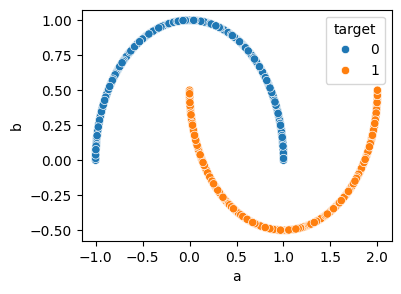

In [42]:
plt.figure(figsize=(4,3))
sns.scatterplot(x='a', y='b', data=dataset, hue='target')
plt.show()

In [43]:
x=dataset.drop(columns='target', axis=1)
y=dataset['target']

In [44]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.3, random_state=42)

In [45]:
from sklearn.ensemble import AdaBoostClassifier
ada=AdaBoostClassifier(estimator=None,n_estimators=100,learning_rate=1.0)
# when estimator is none, it will automatically use DT
# learning_rate=1.0 means the initial weights given to all rows

In [46]:
ada.fit(x_train, y_train)

C:\Users\J11\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


AdaBoostClassifier(n_estimators=100)

In [47]:
ada.score(x_train, y_train)*100, ada.score(x_test, y_test)*100

(100.0, 100.0)

C:\Users\J11\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but AdaBoostClassifier was fitted with feature names
  warnings.warn(


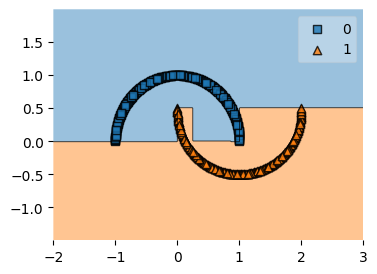

In [48]:
plt.figure(figsize=(4,3))
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(x.to_numpy(), y.to_numpy(), clf=ada)
plt.show() 